## Prediction of movies dataset

In [2]:
from preprocessing_class import Preprocessing, load_movies
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression,LogisticRegressionCV
from sklearn.svm import LinearSVC,SVC
from nltk.corpus import stopwords
from extraction_vocab_bow import basic_bow_exploration

import numpy as np
import string
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

In [12]:
# load dataset
path = "./Dataset/movies1000/"
alltxt,alllabs = load_movies(path)
alltxt, alllabs = np.array(alltxt), np.array(alllabs)


In [3]:
alllabs[0],alltxt[0]

(np.int64(0),
 np.str_('let me just start this review off by saying i am a huge fan of professional wrestling and have been for fifteen years . \ni am not too fond of ted turner\'s world championship wrestling , however , and i am even less fond of it now after seeing this ridiculous excuse for a wrestling movie tonight . \nthe plot concerns two losers named gordie boggs ( david arquette , aptly cast as a neandrathal ) and sean dawkins ( scott caan ) who are so obsessed with professional wrestling that they believe everything they see on wcw monday nitro is something more than a flashy show . \nwhen they finally get to see their hero , wcw world champion jimmy king ( played by oliver platt . \ni personally would have gotten a wrestler to play king ) , he ends up getting screwed over by evil promoter titus sinclair ( a wasted palitaliano , in a role originally meant for real-life wcw president eric bischoff before he was fired and rehired six months later , and if anyone reads this who 

In [4]:
# M = -1, C = 1
len(alltxt), len(alllabs), np.unique(alllabs)

(2000, 2000, array([0, 1]))

[nltk_data] Downloading package stopwords to /home/alant/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


2000 documents
taille origine du vocab: 39659 mots total
['00' '000' '0009f' ... 'zwigoff' 'zycie' 'zzzzzzz'] 

vocab avec les 100 mots plus frequents :
['about' 'after' 'all' 'also' 'an' 'and' 'any' 'are' 'as' 'at' 'be'
 'because' 'been' 'but' 'by' 'can' 'character' 'characters' 'could' 'do'
 'does' 'even' 'film' 'films' 'first' 'for' 'from' 'get' 'good' 'had'
 'has' 'have' 'he' 'her' 'him' 'his' 'how' 'if' 'in' 'into' 'is' 'it'
 'its' 'just' 'life' 'like' 'little' 'make' 'more' 'most' 'movie' 'much'
 'no' 'not' 'of' 'off' 'on' 'one' 'only' 'or' 'other' 'out' 'over'
 'people' 'plot' 'really' 'see' 'she' 'so' 'some' 'story' 'than' 'that'
 'the' 'their' 'them' 'then' 'there' 'they' 'this' 'time' 'to' 'too' 'two'
 'up' 'very' 'was' 'way' 'we' 'well' 'what' 'when' 'where' 'which' 'while'
 'who' 'will' 'with' 'would' 'you'] 

100 mots avec la plus grande frequence doc:
['the' 'and' 'of' 'to' 'is' 'in' 'it' 'that' 'with' 'for' 'as' 'but'
 'this' 'on' 'an' 'by' 'are' 'one' 'be' 'his' 'film' 

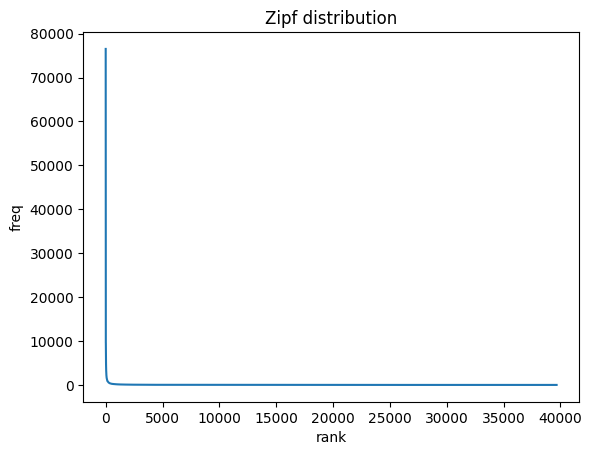

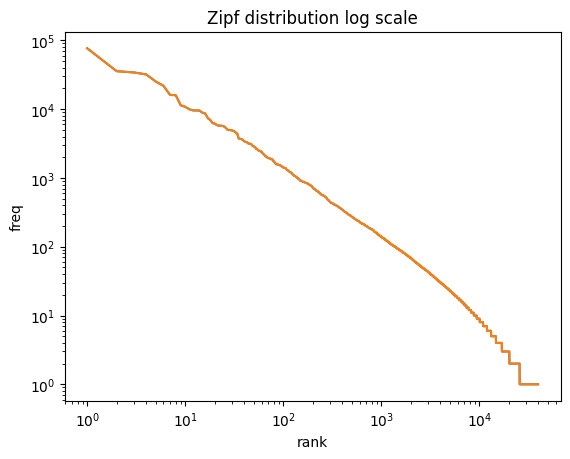


100 bigrammes les plus freq:
['about the' 'all of' 'all the' 'and his' 'and it' 'and the' 'as the'
 'as well' 'at least' 'at the' 'but it' 'but the' 'by the' 'could have'
 'film is' 'for the' 'from the' 'going to' 'has been' 'have been'
 'have to' 'he has' 'he is' 'if you' 'in his' 'in the' 'in this'
 'into the' 'is an' 'is not' 'is one' 'is that' 'is the' 'it is' 'it was'
 'kind of' 'like the' 'lot of' 'more than' 'most of' 'movie is'
 'of course' 'of his' 'of the' 'of them' 'of this' 'on the' 'one of'
 'out of' 'over the' 'played by' 'seems to' 'some of' 'that he' 'that is'
 'that it' 'that the' 'the audience' 'the best' 'the characters' 'the end'
 'the film' 'the first' 'the most' 'the movie' 'the only' 'the other'
 'the plot' 'the rest' 'the same' 'the story' 'the two' 'the way'
 'the world' 'there are' 'there is' 'they are' 'they re' 'this film'
 'this is' 'this movie' 'to be' 'to do' 'to get' 'to have' 'to make'
 'to see' 'to the' 'trying to' 'up to' 'want to' 'when he' 'when th

In [5]:
basic_bow_exploration(alltxt,lang="english")

### Split of the dataset

In [13]:
# train test split here for test in final prediction
strat_split = StratifiedShuffleSplit(1, test_size=0.2, random_state=0)

for i, (train_idx, test_idx) in enumerate(strat_split.split(alltxt, alllabs)):
    print(i)
X_train, y_train, X_test, y_test = alltxt[train_idx], alllabs[train_idx], alltxt[test_idx], alllabs[test_idx]

# further split the train 
for i, (train_idx, test_idx) in enumerate(strat_split.split(X_train, y_train)):
    print(i)
X_train_sub, y_train_sub, X_val, y_val = X_train[train_idx], y_train[train_idx], X_train[test_idx], y_train[test_idx]

0
0


In [4]:
len(X_train_sub), len(y_train_sub), len(X_val), len(y_val), len(X_train), len(y_train), len(X_test), len(y_test)

(1280, 1280, 320, 320, 1600, 1600, 400, 400)

## Experiment 1

Preprocessing:
- lower case
- remove punctuation
- no stemming or lemmatization
- keep all capital words and accents

Vectorizer:
- CountVectorizer

Model:
- Logistic Regression

In [25]:
prep = Preprocessing(low_case = True,
        rm_punctuation = True,
        rm_number = False,
        word_norm = None, # stem faster
        pos_tagging = False, # to check
        all_capital = True, # keep all capital words as they are
        cap_name = True, # garder les noms en majuscules, for pos tag
        rm_accent = True, 
        lang = "english",
        punct = string.punctuation + '\n\r\t', # punctuation can contain -, that would be kept
        urls = False 
    )


In [5]:
# vectorization  

final_stopwords_list = stopwords.words('english') 

def build_vectorizer(name="count", stop_words=None, max_features=1000,
                     lowercase=False, strip_accents=None, ngram_range=(1,1), use_idf= True, smooth_idf=True, sublinear_tf=False, 
                     max_df=0.95, min_df=2, preprocessor = lambda x: x):
    if name == "count":
        vectorizer = CountVectorizer(stop_words=stop_words,max_features=max_features,max_df=max_df,min_df=min_df,ngram_range=ngram_range,lowercase=lowercase,
                                     strip_accents=strip_accents, preprocessor=preprocessor)    
        
    elif name == "tfidf":
        vectorizer = TfidfVectorizer(use_idf= use_idf, smooth_idf=smooth_idf, sublinear_tf=sublinear_tf,max_df=max_df, min_df=min_df, max_features=max_features,
                                     stop_words=stop_words, ngram_range=ngram_range,lowercase=lowercase,strip_accents=strip_accents, preprocessor=preprocessor)    
    return vectorizer

def vectorize_txts(txts,vectorizer):
    X = vectorizer.fit_transform(txts)
    return X

In [27]:
# building vectorizer on the train set

vectoriser = build_vectorizer(name="count", stop_words=final_stopwords_list, max_features=1000, preprocessor=prep)

# train on the sub train
vectorised_train_sub = vectoriser.fit_transform(X_train_sub)
vectorised_val = vectoriser.transform(X_val)

In [28]:
# get the vocabulary and the frequency -> used to check and restreint vocab

import pandas as pd

word_counts = vectorised_train_sub.sum(axis=0).A1  # .A1 flattens it into a 1D array
words = vectoriser.get_feature_names_out()

df_vocab = pd.DataFrame({'word': words, 'count': word_counts})
df_ranked = df_vocab.sort_values(by='count', ascending=False)

print(df_ranked.head(10))

      word  count
308   film   6025
604    one   3708
563  movie   3626
489   like   2355
261   even   1648
362   good   1530
889   time   1514
832  story   1363
988  would   1322
567   much   1296


In [29]:
len(df_ranked)

1000

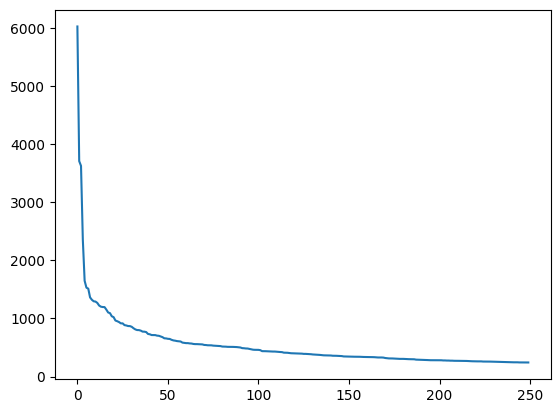

In [30]:
# distribution
plt.plot(df_ranked["count"].head(250).values) # 161 words vocab ok
# plt.yscale("log")

### Running models
#### On simple split

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import average_precision_score

## solver = 'newton-cholesky' to try for logistic regression (n_samples >> n_features * n_classes, especially with one-hot encoded categorical features with rare categories)
def build_model(name="kmeans", n_clusters = 2, max_iter = 1000, penalty='l2', loss='squared_hinge',kernel='rbf',solver='lbfgs'):
    if name == "kmeans":
        return KMeans(n_clusters=n_clusters,max_iter=max_iter) 
    elif name == "linear_svm":
        return LinearSVC(penalty=penalty,loss=loss,max_iter=max_iter)
    elif name == "svm":
        return SVC(max_iter=max_iter,kernel=kernel)
    elif name == "logreg":
        return LogisticRegression(solver=solver,max_iter=max_iter) 

def pipeline(model, X_train, y_train, X_test, y_test):
    # fit and preidct Xtrain, Xtest 
    model.fit(X_train,y_train)

    # preds
    y_pred_train = model.predict(X_train)
    ypred_train_prob = model.predict_proba(X_train) # probas for ROC

    y_pred = model.predict(X_test)
    ypred_prob = model.predict_proba(X_test)

    print(f1_score(y_train,y_pred_train),f1_score(y_test,y_pred))
    print(average_precision_score(y_train,y_pred_train), average_precision_score(y_test,y_pred))
    # print(roc_auc_score(y_train, ypred_train_prob), f1_score(y_test,ypred_prob))

    ConfusionMatrixDisplay.from_estimator(model, X_train, y_train)
    plt.show()
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
    plt.show()

    return model

1.0 0.7590361445783133
1.0 0.6831395348837208


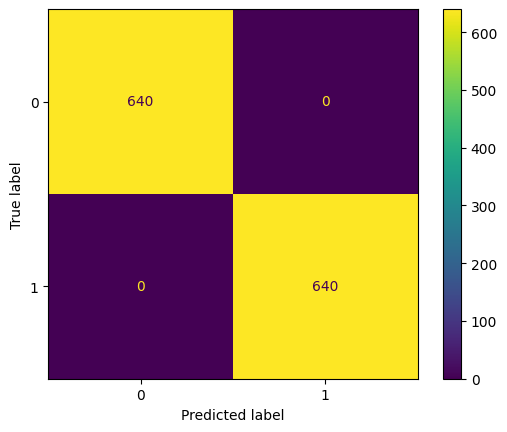

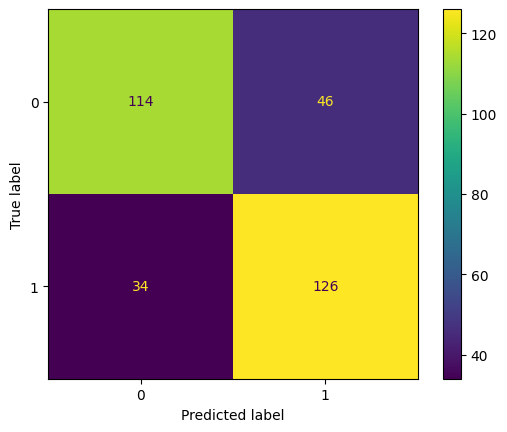

In [32]:
lr = build_model(name="logreg")
lr = pipeline(lr, vectorised_train_sub, y_train_sub, vectorised_val, y_val)

#### Cross validation, then test

In [13]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

# Plot CV train vs validation metrics across folds + test as reference line

def plot(train_cv_metrics, val_cv_metrics, test_metrics):

    metric_names = ["AUC", "F1", "Average Precision", "Recall", "Precision"]
    folds = np.arange(1, len(val_cv_metrics["AUC"]) + 1)

    fig, axes = plt.subplots(1, len(metric_names), figsize=(24, 4), sharex=True)

    for ax, metric_name in zip(axes, metric_names):
        train_vals = train_cv_metrics[metric_name]
        val_vals = val_cv_metrics[metric_name]
        test_val = test_metrics[metric_name]

        ax.plot(folds, train_vals, marker="o", label="Train CV")
        ax.plot(folds, val_vals, marker="o", label="Validation CV")
        ax.axhline(test_val, linestyle="--", linewidth=2, label="Test")

        ax.set_title(metric_name)
        ax.set_xlabel("Fold")
        ax.set_xticks(folds)
        ax.grid(alpha=0.25)

    axes[0].set_ylabel("Score")
    handles, labels = axes[-1].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=3)
    plt.suptitle("Cross-validation metrics (Train vs Validation) with Test reference", y=1.12)
    plt.tight_layout()
    plt.legend()
    plt.show()

def cv_train(model, kwargs, vect_kwargs, X_train, y_train, X_test, y_test, cv=5, test_size=0.2):
    # split in train val, do a cross validation, then evaluate on the final test set
    # takes in untrained model

    train_cv_metrics = {
        "AUC": [],
        "F1": [],
        "Average Precision": [],
        "Recall": [],
        "Precision": [],
    }

    val_cv_metrics = {
        "AUC": [],
        "F1": [],
        "Average Precision": [],
        "Recall": [],
        "Precision": [],
    }

    # splits
    cv_splits = StratifiedShuffleSplit(cv, test_size=test_size, random_state=0)
    for i, (train_idx, test_idx) in enumerate(cv_splits.split(X_train, y_train)):
        print("Fold ", i)
        X_train_sub, y_train_sub, X_val, y_val = X_train[train_idx], y_train[train_idx], X_train[test_idx], y_train[test_idx]

        # vectorising
        vectoriser = build_vectorizer(**vect_kwargs)

        # train on the sub train
        vect_train_sub = vectoriser.fit_transform(X_train_sub)
        vect_val = vectoriser.transform(X_val)

        clf = model(**kwargs)
        clf.fit(vect_train_sub, y_train_sub)

        # predictions
        y_pred_train = clf.predict(vect_train_sub)
        ypred_train_prob = clf.predict_proba(vect_train_sub)[:, 1]  # probas for ROC

        y_pred = clf.predict(vect_val)
        ypred_prob = clf.predict_proba(vect_val)[:, 1]

        # evaluation
        f1_train, f1_val = f1_score(y_train_sub, y_pred_train), f1_score(y_val, y_pred)
        ap_train, ap_val = average_precision_score(y_train_sub, y_pred_train), average_precision_score(y_val, y_pred)
        auc_train, auc_val = roc_auc_score(y_train_sub, ypred_train_prob), roc_auc_score(y_val, ypred_prob)
        prec_train, prec_val = precision_score(y_train_sub, y_pred_train), precision_score(y_val, y_pred)
        rec_train, rec_val = recall_score(y_train_sub, y_pred_train), recall_score(y_val, y_pred)

        train_cv_metrics["AUC"].append(auc_train)
        train_cv_metrics["F1"].append(f1_train)
        train_cv_metrics["Average Precision"].append(ap_train)
        train_cv_metrics["Recall"].append(rec_train)
        train_cv_metrics["Precision"].append(prec_train)

        val_cv_metrics["AUC"].append(auc_val)
        val_cv_metrics["F1"].append(f1_val)
        val_cv_metrics["Average Precision"].append(ap_val)
        val_cv_metrics["Recall"].append(rec_val)
        val_cv_metrics["Precision"].append(prec_val)

    # final test evaluation
    vectoriser = build_vectorizer(**vect_kwargs)

    vect_train = vectoriser.fit_transform(X_train)
    vect_test = vectoriser.transform(X_test)

    clf = model(**kwargs)
    clf.fit(vect_train, y_train)

    y_pred_train = clf.predict(vect_train)
    ypred_train_prob = clf.predict_proba(vect_train)[:, 1]  # probas for ROC

    y_pred = clf.predict(vect_test)
    ypred_prob = clf.predict_proba(vect_test)[:, 1]

    f1_train, f1_test = f1_score(y_train, y_pred_train), f1_score(y_test, y_pred)
    ap_train, ap_test = average_precision_score(y_train, y_pred_train), average_precision_score(y_test, y_pred)
    auc_train, auc_test = roc_auc_score(y_train, ypred_train_prob), roc_auc_score(y_test, ypred_prob)
    prec_train, prec_test = precision_score(y_train, y_pred_train), precision_score(y_test, y_pred)
    rec_train, rec_test = recall_score(y_train, y_pred_train), recall_score(y_test, y_pred)

    final_train_metrics = {
        "AUC": auc_train,
        "F1": f1_train,
        "Average Precision": ap_train,
        "Recall": rec_train,
        "Precision": prec_train,
    }

    test_metrics = {
        "AUC": auc_test,
        "F1": f1_test,
        "Average Precision": ap_test,
        "Recall": rec_test,
        "Precision": prec_test,
    }

    # print summary
    print("Final Train Results:")
    for metric_name, metric_value in final_train_metrics.items():
        print(f"{metric_name}: {metric_value}")

    print("\nFinal Test Results:")
    for metric_name, metric_value in test_metrics.items():
        print(f"{metric_name}: {metric_value}")

    plot(train_cv_metrics, val_cv_metrics, test_metrics)

Fold  0
Fold  1
Fold  2
Fold  3
Fold  4
Final Train Results:
AUC: 1.0
F1: 1.0
Average Precision: 1.0
Recall: 1.0
Precision: 1.0

Final Test Results:
AUC: 0.916775
F1: 0.8270676691729323
Average Precision: 0.7715452261306532
Recall: 0.825
Precision: 0.8291457286432161


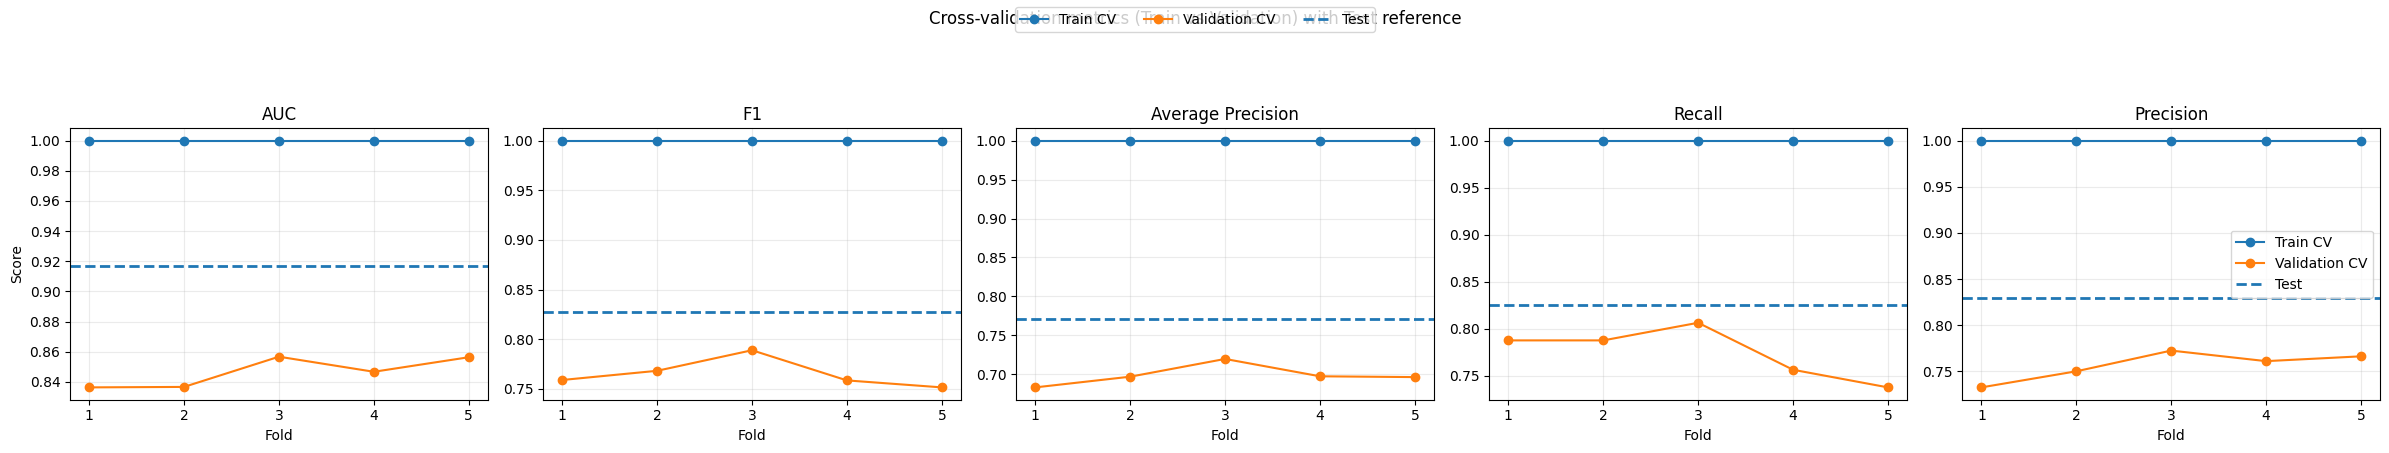

In [45]:
prep = Preprocessing(low_case = True,
        rm_punctuation = True,
        rm_number = False,
        word_norm = None, # stem faster
        pos_tagging = False, # to check
        all_capital = True, # keep all capital words as they are
        cap_name = True, # garder les noms en majuscules, for pos tag
        rm_accent = True, 
        lang = "english",
        punct = string.punctuation + '\n\r\t', # punctuation can contain -, that would be kept
        urls = False 
    )

cv_train(LogisticRegression,
    {"solver": "lbfgs", "max_iter": 1000}, 
    {"name":"count", "stop_words":final_stopwords_list, "max_features":1000, "preprocessor":prep},
    X_train,
    y_train,
    X_test,
    y_test,
    cv=5,
    test_size=0.2)

#### Model on final train and test 

In [14]:
def eval_test(model, kwargs, vect_kwargs, X_train, y_train, X_test, y_test):
    # vectorising
    vectorizer = build_vectorizer(**vect_kwargs)
    vect_train = vectorizer.fit_transform(X_train)
    vect_test = vectorizer.transform(X_test)

    clf = model(**kwargs)
    clf.fit(vect_train, y_train)

    y_pred_train = clf.predict(vect_train)
    ypred_train_prob = clf.predict_proba(vect_train)[:, 1]  # probas for ROC

    y_pred = clf.predict(vect_test)
    ypred_prob = clf.predict_proba(vect_test)[:, 1]

    f1_train, f1_test = f1_score(y_train, y_pred_train), f1_score(y_test, y_pred)
    ap_train, ap_test = average_precision_score(y_train, y_pred_train), average_precision_score(y_test, y_pred)
    auc_train, auc_test = roc_auc_score(y_train, ypred_train_prob), roc_auc_score(y_test, ypred_prob)
    prec_train, prec_test = precision_score(y_train, y_pred_train), precision_score(y_test, y_pred)
    rec_train, rec_test = recall_score(y_train, y_pred_train), recall_score(y_test, y_pred)

    final_train_metrics = {
        "AUC": auc_train,
        "F1": f1_train,
        "Average Precision": ap_train,
        "Recall": rec_train,
        "Precision": prec_train,
    }

    test_metrics = {
        "AUC": auc_test,
        "F1": f1_test,
        "Average Precision": ap_test,
        "Recall": rec_test,
        "Precision": prec_test,
    }

    # print summary
    print("Final Train Results:")
    for metric_name, metric_value in final_train_metrics.items():
        print(f"{metric_name}: {metric_value}")

    print("\nFinal Test Results:")
    for metric_name, metric_value in test_metrics.items():
        print(f"{metric_name}: {metric_value}")

In [36]:
eval_test(LogisticRegression,
    {"solver": "lbfgs", "max_iter": 1000},
    {"name":"count", "stop_words":final_stopwords_list, "max_features":1000, "preprocessor":prep},
    X_train,
    y_train,
    X_test,
    y_test,)

Final Train Results:
AUC: 1.0
F1: 1.0
Average Precision: 1.0
Recall: 1.0
Precision: 1.0

Final Test Results:
AUC: 0.916775
F1: 0.8270676691729323
Average Precision: 0.7715452261306532
Recall: 0.825
Precision: 0.8291457286432161


## Experiment 2 with tfidf

same Preprocessing as 1
- lower case
- remove punctuation
- no stemming or lemmatization
- keep all capital words and accents

Vectorizer:
- TfidfVectorizer

Model:
- Logistic Regression

Fold  0
Fold  1
Fold  2
Fold  3
Fold  4
Final Train Results:
AUC: 0.9745765625
F1: 0.9164588528678305
Average Precision: 0.880527052238806
Recall: 0.91875
Precision: 0.914179104477612

Final Test Results:
AUC: 0.92715
F1: 0.8391959798994975
Average Precision: 0.7867676767676768
Recall: 0.835
Precision: 0.8434343434343434


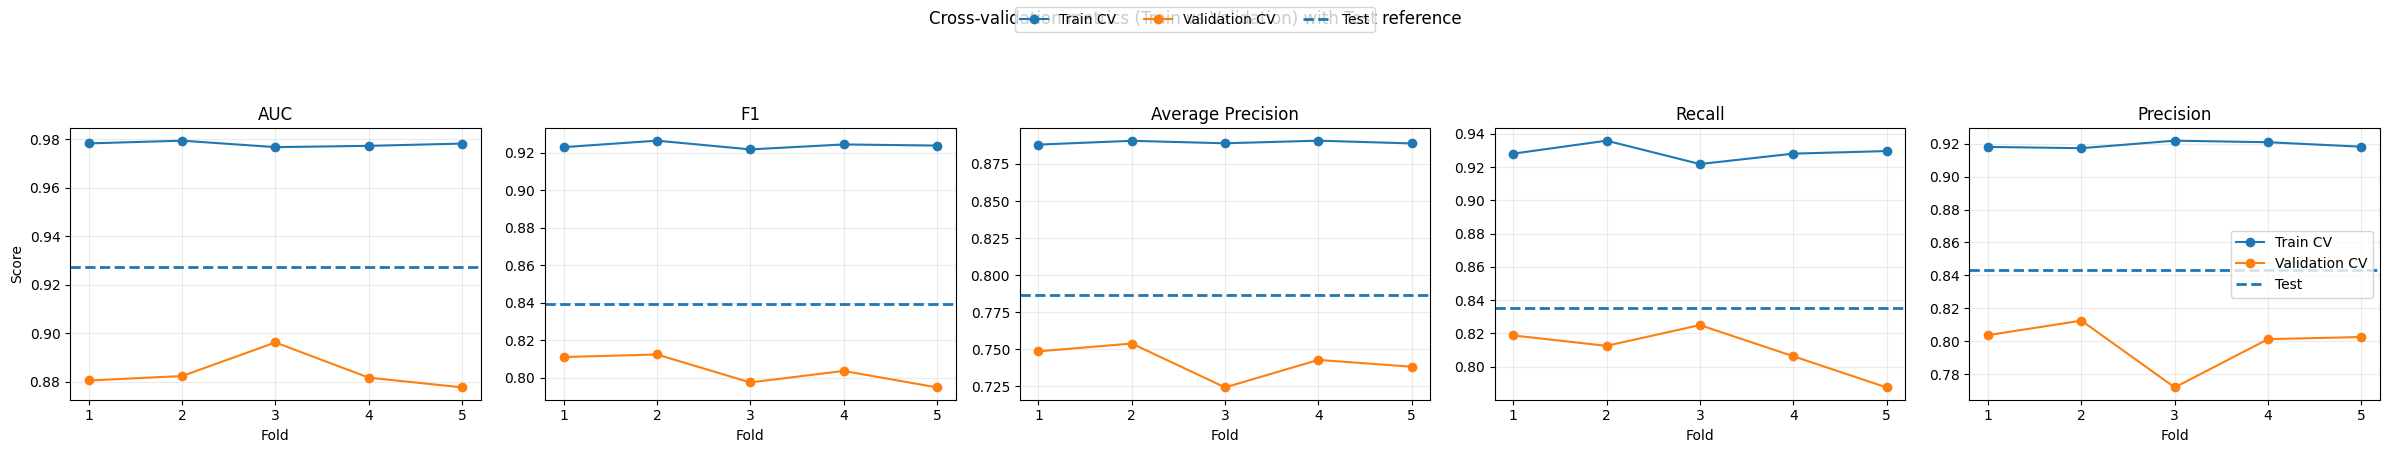

In [39]:
cv_train(LogisticRegression,
    {"solver": "lbfgs", "max_iter": 1000},
    {"name":"tfidf", "stop_words":final_stopwords_list, "max_features":1000, "preprocessor":prep},
    X_train,
    y_train,
    X_test,
    y_test,
    cv=5,
    test_size=0.2)

## Experiment 3 with stemming

Preprocessing:
- lower case
- remove punctuation
- stemming 
- keep all capital words and accents
- remove numbers

Vectorizer:
- Tfidf

Model:
- Logistic Regression

In [42]:
prep = Preprocessing(low_case = True,
                rm_punctuation = True,
                rm_number = True,
                word_norm = "stem", # stem faster
                pos_tagging = False, # to check
                all_capital = True, # keep all capital words as they are
                cap_name = True, # garder les noms en majuscules, for pos tag
                rm_accent = False, 
                lang = "french",
                punct = string.punctuation + '\n\r\t',
                urls = False 
                )

from nltk.stem import SnowballStemmer 
stemmer = SnowballStemmer("english")
stemmed_stopwords = [stemmer.stem(word) for word in final_stopwords_list]

Fold  0
Fold  1
Fold  2
Fold  3
Fold  4
Final Train Results:
AUC: 0.975428125
F1: 0.9224084419615146
Average Precision: 0.8865020036991369
Recall: 0.92875
Precision: 0.9161528976572133

Final Test Results:
AUC: 0.9318
F1: 0.8471177944862155
Average Precision: 0.7951130653266332
Recall: 0.845
Precision: 0.8492462311557789


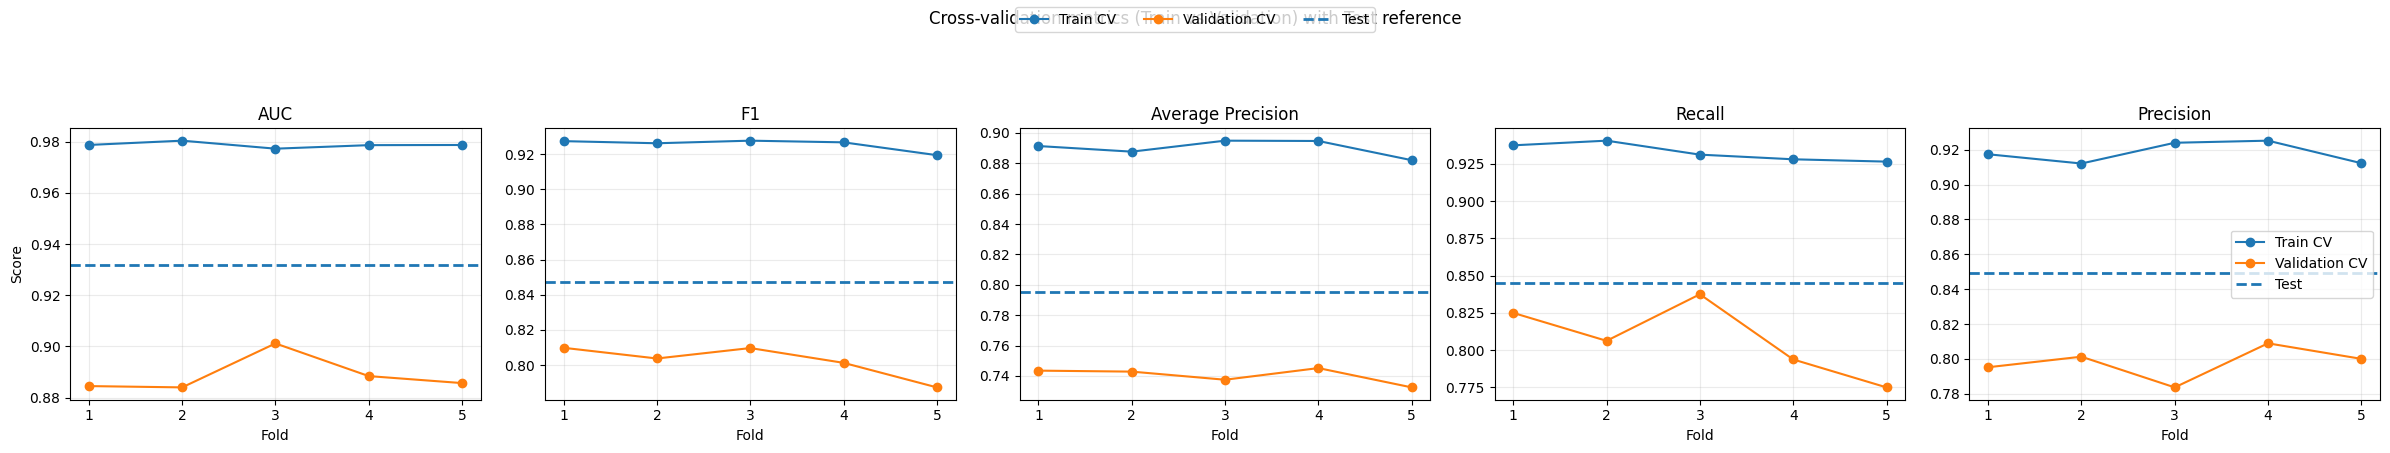

In [48]:
cv_train(LogisticRegression,
    {"solver": "lbfgs", "max_iter": 1000}, 
    {"name":"tfidf", "stop_words":stemmed_stopwords, "max_features":1000, "preprocessor":prep},
    X_train,
    y_train,
    X_test,
    y_test,
    cv=5,
    test_size=0.2)

## Experiment 4 with lemma

In [49]:
prep = Preprocessing(low_case = True,
                rm_punctuation = True,
                rm_number = True,
                word_norm = "lemma",
                pos_tagging = False, 
                all_capital = True, 
                cap_name = True, # garder les noms en majuscules, for pos tag
                rm_accent = False, 
                lang = "english",
                punct = string.punctuation + '\n\r\t',
                urls = False 
                )

In [50]:
import spacy
NLP_ENG = spacy.load('en_core_web_sm',disable=["parser", "ner"])

lemma_stopwords = []

for word in final_stopwords_list:
    doc = NLP_ENG(word)
    for token in doc:
        lemma_stopwords.append(token.lemma_.lower())

Fold  0
Fold  1
Fold  2
Fold  3
Fold  4
Final Train Results:
AUC: 0.9728640625000001
F1: 0.9135338345864662
Average Precision: 0.8789243090452261
Recall: 0.91125
Precision: 0.9158291457286433

Final Test Results:
AUC: 0.918225
F1: 0.8235294117647058
Average Precision: 0.7760602094240838
Recall: 0.805
Precision: 0.8429319371727748


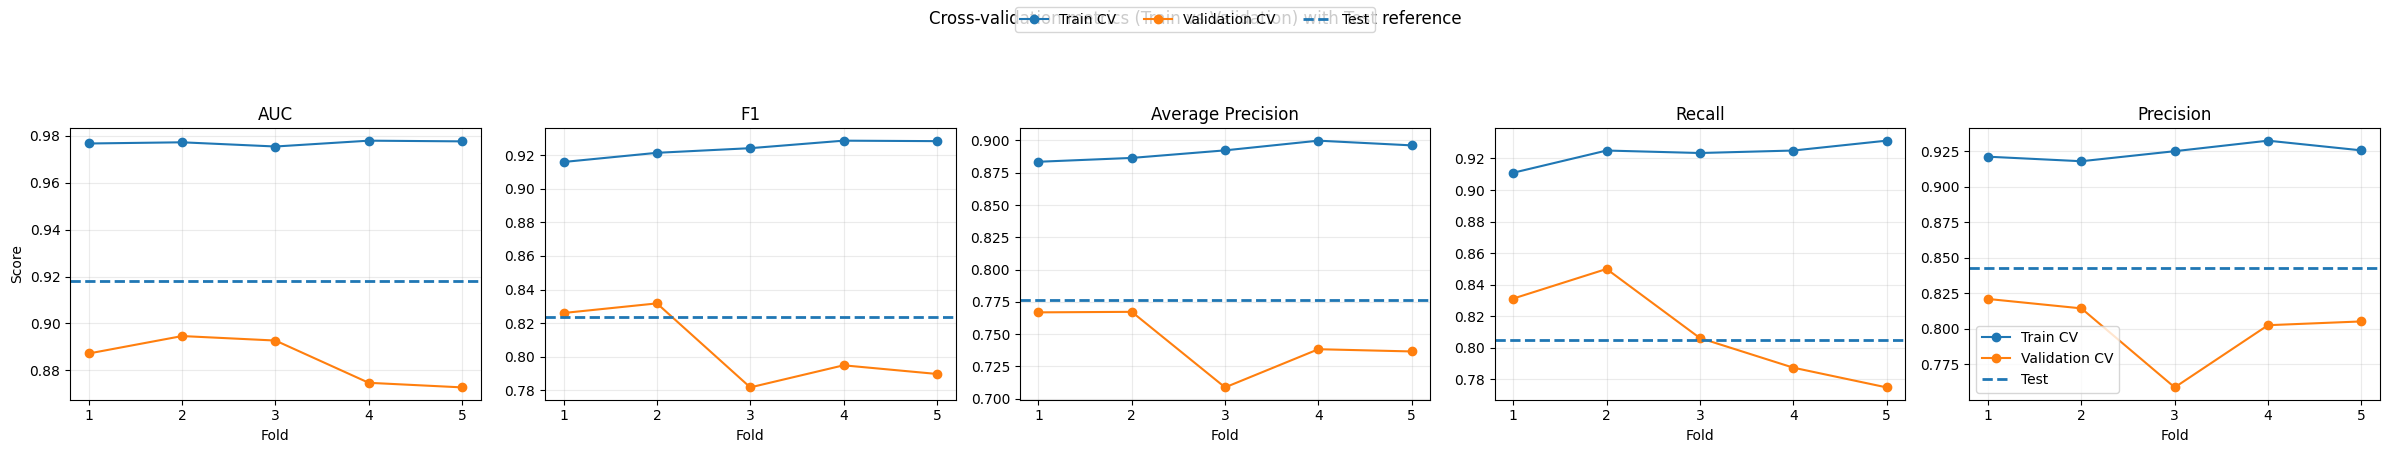

In [51]:
cv_train(LogisticRegression,
    {"solver": "lbfgs", "max_iter": 1000}, 
    {"name":"tfidf", "stop_words":lemma_stopwords, "max_features":1000, "preprocessor":prep},
    X_train,
    y_train,
    X_test,
    y_test,
    cv=5,
    test_size=0.2)

## Experiment 5 with embeddings

Preprocessing:
- lower case
- remove punctuation
- no stemming or lemmatization
- keep all capital words and accents
- language english
- remove numbers

Vectorizer:
- Embeddings (word2vec)

Model:
- Logistic Regression

In [12]:
prep = Preprocessing(low_case = True,
                rm_punctuation = True,
                rm_number = True,
                word_norm = None, # stem faster
                pos_tagging = False, # to check
                all_capital = True, # keep all capital words as they are
                cap_name = True, # garder les noms en majuscules, for pos tag
                rm_accent = False, 
                lang = "english",
                punct = string.punctuation + '\n\r\t',
                urls = False 
                )

In [12]:
import gensim
import logging
logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.INFO)

# preprocess the train before word2vec
prep_X_train = [prep.process(txt) for txt in X_train]

text = [t.split() for t in prep_X_train]

w2v = gensim.models.word2vec.Word2Vec(sentences=text,
                                vector_size=100, window=5,               ### here we train a cbow model
                                min_count=5,
                                sample=0.001, workers=3,
                                sg=1, hs=0, negative=5,        ### set sg to 1 to train a sg model
                                cbow_mean=1, epochs=5)

w2v.save("W2v-movie-exp5.dat")

# w2v = gensim.models.Word2Vec.load("W2v-movie-exp5.dat")

def embed(text, w2v, mean=False, min = False, max = False):
    """
    This function should vectorize one review

    input: str
    output: np.array(float)
    """ 
    vec = []
    keys = w2v.wv.key_to_index.keys()

    # sum 'urllib' has no attribute 'parse'
    for word in text:
        if word in keys:
            idx = w2v.wv.key_to_index[word] 
            vec.append(w2v.wv[idx])
    
    if len(vec) == 0:
        return np.zeros(w2v.vector_size)
    if mean:
        return np.mean(vec, axis = 0)
    if min:
        return np.min(vec, axis = 0)
    if max:
        return np.max(vec, axis = 0)
    return np.sum(vec, axis = 0)


2026-03-17 00:46:21,571 : INFO : collecting all words and their counts
2026-03-17 00:46:21,572 : INFO : PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
2026-03-17 00:46:21,711 : INFO : collected 35871 word types from a corpus of 1063115 raw words and 1600 sentences
2026-03-17 00:46:21,712 : INFO : Creating a fresh vocabulary
2026-03-17 00:46:21,748 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=5 retains 12893 unique words (35.94% of original 35871, drops 22978)', 'datetime': '2026-03-17T00:46:21.748277', 'gensim': '4.4.0', 'python': '3.12.13 (main, Mar 10 2026, 18:17:25) [Clang 21.1.4 ]', 'platform': 'Linux-6.8.0-101-generic-x86_64-with-glibc2.35', 'event': 'prepare_vocab'}
2026-03-17 00:46:21,748 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=5 leaves 1023006 word corpus (96.23% of original 1063115, drops 40109)', 'datetime': '2026-03-17T00:46:21.748770', 'gensim': '4.4.0', 'python': '3.12.13 (main, Mar 10 2026, 18:17:25) [Clang 21.1.

In [14]:
prep_X_test = [prep.process(txt) for txt in X_test]

prep_X_train_vect = [embed(text, w2v) for text in prep_X_train]
prep_X_test_vect = [embed(text, w2v) for text in prep_X_test]

In [15]:
from sklearn import preprocessing

def eval_test_vect(model, kwargs, X_train, y_train, X_test, y_test):
    # pass the vectorized train and tes    
    # scaling
    scaler = preprocessing.StandardScaler(with_mean=False).fit(X_train) # avoid dense matrix
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    clf = model(**kwargs)
    clf.fit(X_train_scaled, y_train)

    y_pred_train = clf.predict(X_train_scaled)
    ypred_train_prob = clf.predict_proba(X_train_scaled)[:, 1]  # probas for ROC

    y_pred = clf.predict(X_test_scaled)
    ypred_prob = clf.predict_proba(X_test_scaled)[:, 1]

    f1_train, f1_test = f1_score(y_train, y_pred_train), f1_score(y_test, y_pred)
    ap_train, ap_test = average_precision_score(y_train, y_pred_train), average_precision_score(y_test, y_pred)
    auc_train, auc_test = roc_auc_score(y_train, ypred_train_prob), roc_auc_score(y_test, ypred_prob)
    prec_train, prec_test = precision_score(y_train, y_pred_train), precision_score(y_test, y_pred)
    rec_train, rec_test = recall_score(y_train, y_pred_train), recall_score(y_test, y_pred)

    final_train_metrics = {
        "AUC": auc_train,
        "F1": f1_train,
        "Average Precision": ap_train,
        "Recall": rec_train,
        "Precision": prec_train,
    }

    test_metrics = {
        "AUC": auc_test,
        "F1": f1_test,
        "Average Precision": ap_test,
        "Recall": rec_test,
        "Precision": prec_test,
    }

    # print summary
    print("Final Train Results:")
    for metric_name, metric_value in final_train_metrics.items():
        print(f"{metric_name}: {metric_value}")

    print("\nFinal Test Results:")
    for metric_name, metric_value in test_metrics.items():
        print(f"{metric_name}: {metric_value}")

In [16]:
lr = build_model(name="logreg")

eval_test_vect(LogisticRegression,
    {"solver": "lbfgs", "max_iter": 1000},
    prep_X_train_vect,
    y_train,    
    prep_X_test_vect,
    y_test
)

Final Train Results:
AUC: 0.6849546875
F1: 0.6163934426229508
Average Precision: 0.5871120689655172
Recall: 0.5875
Precision: 0.6482758620689655

Final Test Results:
AUC: 0.69565
F1: 0.6342710997442456
Average Precision: 0.5925130890052357
Recall: 0.62
Precision: 0.6492146596858639


## Experiment 6 with RNN

In [6]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, f1_score, average_precision_score, recall_score, precision_score
import gensim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

w2v = gensim.models.Word2Vec.load("W2v-movie-exp5.dat")
w2v.wv.key_to_index,len(w2v.wv.key_to_index)

({'the': 0,
  'a': 1,
  'and': 2,
  'of': 3,
  'to': 4,
  'is': 5,
  'in': 6,
  's': 7,
  'it': 8,
  'that': 9,
  'as': 10,
  'with': 11,
  'for': 12,
  'film': 13,
  'this': 14,
  'his': 15,
  'i': 16,
  'he': 17,
  'but': 18,
  'on': 19,
  'are': 20,
  't': 21,
  'by': 22,
  'be': 23,
  'one': 24,
  'movie': 25,
  'an': 26,
  'who': 27,
  'not': 28,
  'you': 29,
  'from': 30,
  'at': 31,
  'was': 32,
  'they': 33,
  'have': 34,
  'has': 35,
  'her': 36,
  'all': 37,
  'there': 38,
  'like': 39,
  'so': 40,
  'out': 41,
  'about': 42,
  'up': 43,
  'what': 44,
  'more': 45,
  'when': 46,
  'or': 47,
  'which': 48,
  'their': 49,
  'she': 50,
  'some': 51,
  'just': 52,
  'can': 53,
  'if': 54,
  'we': 55,
  'him': 56,
  'into': 57,
  'even': 58,
  'only': 59,
  'no': 60,
  'than': 61,
  'time': 62,
  'good': 63,
  'most': 64,
  'story': 65,
  'its': 66,
  'will': 67,
  'would': 68,
  'character': 69,
  'much': 70,
  'been': 71,
  'other': 72,
  'also': 73,
  'two': 74,
  'well': 75,
 

In [13]:

word2idx = {"<PAD>": 0, "<UNK>": 1}

# word2idx built from w2v
for w in w2v.wv.key_to_index.keys():
    word2idx[w] = len(word2idx)

vocab_size = len(word2idx)
embed_dim = w2v.vector_size  # 100

# emedding matrix = (vocab size,100)
embedding_matrix = np.zeros((vocab_size, embed_dim), dtype=np.float32)
for w, i in word2idx.items():
    if w in w2v.wv.key_to_index:
        embedding_matrix[i] = w2v.wv[w]
    # PAD and UNK stay as zero (or random if you prefer)

def text_to_indices(text, word2idx):
    """Takes text: a single review. Returns list of embedded tokens"""
    t = prep.process(text)
    tokens = t.split()
    return [word2idx.get(tok, word2idx["<UNK>"]) for tok in tokens]

X_train_ids = [text_to_indices(t, word2idx) for t in X_train_sub]
X_val_ids   = [text_to_indices(t, word2idx) for t in X_val]
X_test_ids  = [text_to_indices(t, word2idx) for t in X_test]


In [14]:
class ReviewsDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = labels

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return torch.tensor(self.sequences[idx], dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.float32)


def pad_collate(batch):
    """batch: list of (seq_tensor, label_tensor). Returns (tensor of padded seqs, tensor of original lengths, labels) """
    seqs, labels = zip(*batch)
    lengths = torch.tensor([len(s) for s in seqs], dtype=torch.long)
    padded = torch.nn.utils.rnn.pad_sequence(seqs, batch_first=True, padding_value=0) # size B*T*x where T = length of longest seq
    labels = torch.stack(labels)
    return padded, lengths, labels


batch_size = 32

train_dataset = ReviewsDataset(X_train_ids, y_train_sub)
val_dataset   = ReviewsDataset(X_val_ids, y_val)
test_dataset  = ReviewsDataset(X_test_ids, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=pad_collate)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=pad_collate)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=pad_collate)


In [15]:
import torch.nn as nn

class RNNClassifier(nn.Module):
    def __init__(self, type, vocab_size, embed_dim, hidden_dim, num_layers, embedding_matrix):
        super().__init__()
        self.t = type
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))
        
        # fine-tune w2v by removing this line
        self.embedding.weight.requires_grad = False

        if type=="lstm":
            self.rnn = nn.LSTM(
                input_size=embed_dim,
                hidden_size=hidden_dim,
                batch_first=True,
                num_layers=num_layers,
                bidirectional=False
            )
        elif type=="gru":
            self.rnn = nn.GRU(
                input_size=embed_dim,
                hidden_size=hidden_dim,
                batch_first=True,
                num_layers=num_layers,
                bidirectional=False
            )

        else:
            self.rnn = nn.RNN(
                input_size=embed_dim,
                hidden_size=hidden_dim,
                batch_first=True,
                num_layers=num_layers,
                bidirectional=False
            )

        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x, lengths):
        # x: (batch, seq_len)
        embedded = self.embedding(x)  # (batch, seq_len, embed_dim)

        # pack padded sequence
        packed = nn.utils.rnn.pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
        
        if self.t == "lstm":
            # for LSTM, h_n: (num_layers * num_directions, batch, hidden_dim)
            packed_out, (h_n, c_n) = self.rnn(packed)
        else:
            # for RNN vanilla, GRU
            packed_out, h_n = self.rnn(packed)

        last_hidden = h_n[-1]  # (batch, hidden_dim)
        logits = self.fc(last_hidden).squeeze(1)  # (batch,)
        return logits

num_layers = 3
hidden_dim = 128
model = RNNClassifier("gru", vocab_size, embed_dim, hidden_dim, num_layers, embedding_matrix).to(device)
criterion = nn.BCEWithLogitsLoss()  # combines sigmoid + BCELoss
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)


In [16]:
def compute_metrics(y_true, y_prob):
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    y_pred = (y_prob >= 0.5).astype(int)

    auc = roc_auc_score(y_true, y_prob)
    f1 = f1_score(y_true, y_pred)
    ap = average_precision_score(y_true, y_prob)
    rec = recall_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)

    return {
        "AUC": auc,
        "F1": f1,
        "Average Precision": ap,
        "Recall": rec,
        "Precision": prec,
    }

def train_model(model, train_loader, val_loader, epochs=5,verbose=True):
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
    }

    for epoch in range(1, epochs+1):
        model.train()
        train_losses = []
        train_correct = 0
        train_total = 0

        for x, lengths, y in train_loader:
            x = x.to(device)
            lengths = lengths.to(device)
            y = y.to(device)

            optimizer.zero_grad()
            logits = model(x, lengths)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())
            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).float()
            train_correct += (preds == y).sum().item()
            train_total += y.size(0)

        train_loss = np.mean(train_losses)
        train_acc = train_correct / train_total

        # validation
        model.eval()
        val_losses = []
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for x, lengths, y in val_loader:
                x = x.to(device)
                lengths = lengths.to(device)
                y = y.to(device)

                logits = model(x, lengths)
                loss = criterion(logits, y)
                val_losses.append(loss.item())

                probs = torch.sigmoid(logits)
                preds = (probs >= 0.5).float()
                val_correct += (preds == y).sum().item()
                val_total += y.size(0)

        val_loss = np.mean(val_losses)
        val_acc = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if verbose:
            print(f"Epoch {epoch}/{epochs} | "
                  f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
                  f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    return history


In [ ]:
history = train_model(model, train_loader, val_loader, epochs=50)

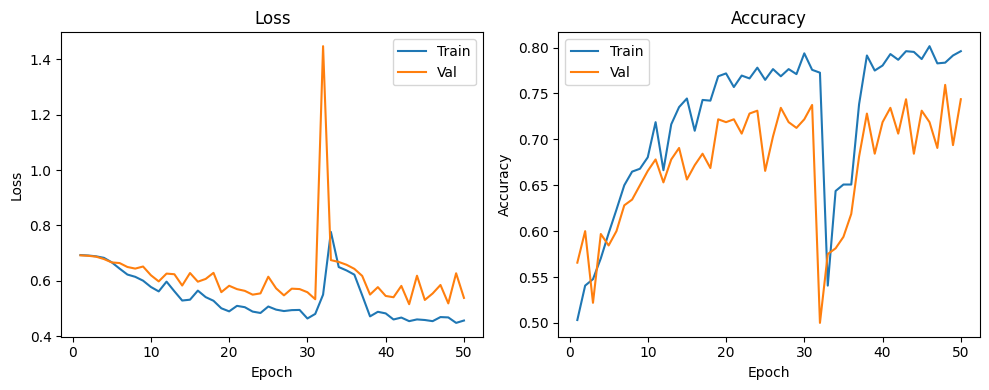

In [ ]:
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(epochs, history["train_loss"], label="Train")
plt.plot(epochs, history["val_loss"], label="Val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(epochs, history["train_acc"], label="Train")
plt.plot(epochs, history["val_acc"], label="Val")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy")

plt.tight_layout()
plt.savefig("images/.pdf")
plt.show()


In [18]:
def evaluate_test(model, loader):
    model.eval()
    all_probs = []
    all_labels = []

    test_losses = []
    with torch.no_grad():
        for x, lengths, y in loader:
            x = x.to(device)
            lengths = lengths.to(device)
            y = y.to(device)

            logits = model(x, lengths)
            loss = criterion(logits, y)
            test_losses.append(loss.item())

            probs = torch.sigmoid(logits).cpu().numpy()
            all_probs.extend(probs.tolist())
            all_labels.extend(y.cpu().numpy().tolist())

    metrics = compute_metrics(all_labels, all_probs)
    test_loss = np.mean(test_losses)
    return test_loss, metrics




In [ ]:
test_loss, test_metrics = evaluate_test(model, test_loader)

print(f"Test Loss: {test_loss:.4f}")
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}")

In [ ]:
selected = [{"type": "rnn", "num_layers": 3, "hidden_dim": 128}, 
            {"type": "lstm", "num_layers": 3, "hidden_dim": 128}, 
            {"type": "gru", "num_layers": 3, "hidden_dim": 128}]

results = []
epochs = 200
lr = 0.0001
print(device)
for t in ["rnn", "lstm", "gru"]:
    print(f"Training {t} model...")
    for num_layers in [1, 2, 3, 5]:
        for hidden_dim in [4, 8, 16]: 
            print(f"Type: {t}, Layers: {num_layers}, Hidden Dim: {hidden_dim}")
            
            model = RNNClassifier(t, vocab_size, embed_dim, hidden_dim, num_layers, embedding_matrix).to(device)
            optimizer = torch.optim.Adam(model.parameters(), lr=lr)
            history = train_model(model, train_loader, val_loader, epochs=epochs, verbose=False)
            test_loss, test_metrics = evaluate_test(model, test_loader)
            
            torch.save(model.state_dict(), f"models/rnns/{t}_e{epochs}_l{num_layers}_h{hidden_dim}.pt")
            
            plt.figure(figsize=(10,4))
            plt.subplot(1,2,1)
            plt.plot(history["train_loss"], label="Train")
            plt.plot(history["val_loss"], label="Val")
            plt.title(f"Loss e={epochs} l={num_layers} h={hidden_dim}")
            plt.legend()
            plt.subplot(1,2,2)
            plt.plot(history["train_acc"], label="Train")
            plt.plot(history["val_acc"], label="Val")
            plt.title("Accuracy")
            plt.legend()
            plt.savefig(f"hyperparam_rnn/plot_{t}_e{epochs}_l{num_layers}_h{hidden_dim}.pdf")
            plt.close()
            
            #saving the histories for pickle dump
            results.append({"type": t, "num_layers": num_layers, "hidden_dim": hidden_dim, "test_metrics": test_metrics, "test_loss": test_loss, "history": history})

import pickle
with open(f"rnn_hyperparam_results_e{epochs}_lr{lr}.pkl", "wb") as f:
    pickle.dump(results, f)

cuda
Training rnn model...
Type: rnn, Layers: 1, Hidden Dim: 4
Type: rnn, Layers: 1, Hidden Dim: 8
Type: rnn, Layers: 1, Hidden Dim: 16
Type: rnn, Layers: 2, Hidden Dim: 4
Type: rnn, Layers: 2, Hidden Dim: 8
Type: rnn, Layers: 2, Hidden Dim: 16
Type: rnn, Layers: 3, Hidden Dim: 4
Type: rnn, Layers: 3, Hidden Dim: 8
Type: rnn, Layers: 3, Hidden Dim: 16
Type: rnn, Layers: 5, Hidden Dim: 4
Type: rnn, Layers: 5, Hidden Dim: 8
Type: rnn, Layers: 5, Hidden Dim: 16
Training lstm model...
Type: lstm, Layers: 1, Hidden Dim: 4
Type: lstm, Layers: 1, Hidden Dim: 8
Type: lstm, Layers: 1, Hidden Dim: 16
Type: lstm, Layers: 2, Hidden Dim: 4
Type: lstm, Layers: 2, Hidden Dim: 8
Type: lstm, Layers: 2, Hidden Dim: 16
Type: lstm, Layers: 3, Hidden Dim: 4
Type: lstm, Layers: 3, Hidden Dim: 8
Type: lstm, Layers: 3, Hidden Dim: 16
Type: lstm, Layers: 5, Hidden Dim: 4
Type: lstm, Layers: 5, Hidden Dim: 8
Type: lstm, Layers: 5, Hidden Dim: 16
Training gru model...
Type: gru, Layers: 1, Hidden Dim: 4
Type: gr

## Experiment 7 Transformers with Tokenizer

In [8]:
from transformers import DistilBertForSequenceClassification, DistilBertTokenizer
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-cased') # smaller

/home/alant/repos/tal-projet/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
## model for classification
# to load first time 
## distilled
#model_name = "distilbert-base-cased"
#model = DistilBertForSequenceClassification.from_pretrained(model_name, cache_dir="./bert_dist_cache")

# or

## bigger
#from transformers import BertForSequenceClassification
#model = BertForSequenceClassification.from_pretrained(model_name, cache_dir="./bert_cache")

# to load from file (distill only here)
model = DistilBertForSequenceClassification.from_pretrained("bert_dist_cache/models--distilbert-base-cased/snapshots/6ea81172465e8b0ad3fddeed32b986cdcdcffcf0")

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 4369.43it/s]
DistilBertForSequenceClassification LOAD REPORT from: bert_dist_cache/models--distilbert-base-cased/snapshots/6ea81172465e8b0ad3fddeed32b986cdcdcffcf0
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [14]:
# tokenize the data
import torch
maxL = 512 # Max length of the sequence

inputs_tokens = []
attention_masks = []

for i in range(len(X_train)):
    if(i%2500==0):
        print(i)
    string_tokenized = tokenizer(X_train[i], return_tensors="pt",
                                        add_special_tokens=True,  # add '[CLS]' and '[SEP]'
                                        max_length=maxL,  # set max length
                                        truncation=True,  # truncate longer messages
                                        #pad_to_max_length=True
                                        padding='max_length',  # add padding
                                        return_attention_mask=True)

    inputs_tokens.append(string_tokenized['input_ids'])
    attention_masks.append(string_tokenized['attention_mask'])

# convert into one big tensor
input_ids = torch.cat(inputs_tokens, dim=0)
attention_masks = torch.cat(attention_masks, dim=0)

0


In [15]:
# tokenize test
maxL = 512 # Max length of the sequence

inputs_tokens_test = []
attention_masks_test = []

for i in range(len(X_test)):
    if(i%2500==0):
        print(i)
    string_tokenized = tokenizer(X_test[i], return_tensors="pt",
                                        add_special_tokens=True,  # add '[CLS]' and '[SEP]'
                                        max_length=maxL,  # set max length
                                        truncation=True,  # truncate longer messages
                                        #pad_to_max_length=True
                                        padding='max_length',  # add padding
                                        return_attention_mask=True)

    inputs_tokens_test.append(string_tokenized['input_ids'])
    attention_masks_test.append(string_tokenized['attention_mask'])

# convert into one big tensor
input_ids_test = torch.cat(inputs_tokens_test, dim=0)
attention_masks_test = torch.cat(attention_masks_test, dim=0)

0


In [16]:
import torch

# saving
#torch.save({
#    "input_ids": input_ids,
#    "attention_masks": attention_masks
#}, "train_tokens_dist.pt")

#torch.save({
#    "input_ids": input_ids_test,
#    "attention_masks": attention_masks_test
#}, "test_tokens_dist.pt")

# # loading
data = torch.load("train_tokens_dist.pt")

input_ids = data["input_ids"]
attention_masks = data["attention_masks"]

data = torch.load("test_tokens_dist.pt")

input_ids_test = data["input_ids"]
attention_masks_test = data["attention_masks"]

In [17]:
# labels to array
y_train_tens = torch.tensor(y_train)
y_test_tens = torch.tensor(y_test) 

# Convert labels from -1/1 → 0/1 (BCE/CE convention)
y_train_tens = ((y_train_tens + 1) // 2).long() 
y_test_tens = ((y_test_tens + 1) // 2).long()

In [18]:
from torch.utils.data import TensorDataset, random_split, DataLoader, RandomSampler, SequentialSampler

dataset_train = TensorDataset(input_ids,  attention_masks, y_train_tens)
dataset_test = TensorDataset(input_ids_test,  attention_masks_test, y_test_tens)

In [19]:
train_dataloader = DataLoader(
    dataset_train,
    batch_size=16,
    shuffle=True
)

test_dataloader = DataLoader(
    dataset_test,
    batch_size=16,
    shuffle=False # f
)

### fine tuning

In [3]:
import gc, torch
gc.collect()
#torch.cuda.empty_cache()

512

In [4]:
!nvidia-smi
torch.cuda.get_device_properties(0) if torch.cuda.is_available() else "No GPU"

Thu Mar 19 23:34:37 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.126.09             Driver Version: 580.126.09     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce GTX 1660 Ti     Off |   00000000:01:00.0  On |                  N/A |
| N/A   47C    P5             13W /   80W |     357MiB /   6144MiB |     18%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

_CudaDeviceProperties(name='NVIDIA GeForce GTX 1660 Ti', major=7, minor=5, total_memory=5747MB, multi_processor_count=24, uuid=aef68030-a754-09e3-aa70-ea6d2c1a83d4, pci_bus_id=1, pci_device_id=0, pci_domain_id=0, L2_cache_size=1MB)

In [10]:
from torch import device
dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(dev)
dev

device(type='cuda')

In [ ]:
from torch.nn import CrossEntropyLoss
loss_fn = CrossEntropyLoss()

In [ ]:
import gc
import json
import tqdm
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
import torch.optim as optim
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, average_precision_score

optimizer = optim.Adam(model.parameters(), lr=2e-5)
epochs = 5
print(dev)
model.to(dev)
epochs_evolution = {}

for epoch in tqdm(range(epochs)):
    model.train()
    total_loss = 0
    all_train_preds = []
    all_train_labels = []
    all_train_logits = []  # collect logits for AUC later

    for batch in tqdm(train_dataloader):
        b_input_ids, b_attention_mask, b_labels = [t.to(dev) for t in batch]
        model.zero_grad()

        outputs = model(
            input_ids=b_input_ids,
            attention_mask=b_attention_mask,
            # labels=b_labels, 
        )

        # loss = outputs.loss
        logits = outputs.logits  # ← was missing in original
        loss = loss_fn(logits, b_labels)

        total_loss += loss.item()
        loss.backward()
        optimizer.step()

        # Move to CPU immediately to free GPU memory
        preds = torch.argmax(logits, dim=1)
        all_train_preds.extend(preds.cpu().numpy())
        all_train_labels.extend(b_labels.cpu().numpy())
        all_train_logits.append(logits.detach().cpu())  # detach before storing


        # ── Free batch tensors ──────────────────────────────────────────
        del b_input_ids, b_attention_mask, b_labels
        del outputs, loss, logits, preds
        torch.cuda.empty_cache()
        gc.collect()
        # ────────────────────────────────────────────────────────────────
    
    avg_train_loss = total_loss / len(train_dataloader)

    # Training metrics
    train_f1        = f1_score(all_train_labels, all_train_preds, average="macro")
    train_precision = precision_score(all_train_labels, all_train_preds, average="macro")
    train_recall    = recall_score(all_train_labels, all_train_preds, average="macro")

    # Stack all logits at once (cleaner than the original list-of-logits approach)
    all_logits_tensor = torch.cat(all_train_logits, dim=0)
    train_probs = torch.softmax(all_logits_tensor, dim=1)[:, 1].numpy()

    train_auc = roc_auc_score(all_train_labels, train_probs)
    train_ap  = average_precision_score(all_train_labels, train_probs)

    print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_train_loss:.4f} | "
          f"F1: {train_f1:.4f} | Precision: {train_precision:.4f} | Recall: {train_recall:.4f} | "
          f"AUC: {train_auc:.4f} | AP: {train_ap:.4f}")
    
    epochs_evolution["epoch"] = [avg_train_loss, train_f1, train_precision, train_recall, train_auc, train_ap]

    # ── Free epoch-level accumulators ───────────────────────────────────
    del all_train_logits, all_logits_tensor, train_probs
    del all_train_preds, all_train_labels
    torch.cuda.empty_cache()
    gc.collect()
    # ────────────────────────────────────────────────────────────────────


# Serialize data into file:
json.dump( epochs_evolution, open( "train_res.json", 'w' ) )


# ── Evaluation ──────────────────────────────────────────────────────────────
model.eval()
all_preds  = []
all_labels = []
all_probs  = []

with torch.no_grad():
    for batch in test_dataloader:
        b_input_ids, b_attention_mask, b_labels = [t.to(dev) for t in batch]

        outputs = model(input_ids=b_input_ids, attention_mask=b_attention_mask, show_progress_bar=True)
        logits  = outputs.logits
        probs   = torch.softmax(logits, dim=1)[:, 1]
        preds   = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(b_labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

        # ── Free batch tensors ──────────────────────────────────────────
        del b_input_ids, b_attention_mask, b_labels
        del outputs, logits, probs, preds
        torch.cuda.empty_cache()
        gc.collect()
        # ────────────────────────────────────────────────────────────────

f1                = f1_score(all_labels, all_preds, average="macro")
precision         = precision_score(all_labels, all_preds, average="macro")
recall            = recall_score(all_labels, all_preds, average="macro")
auc               = roc_auc_score(all_labels, all_probs)
average_precision = average_precision_score(all_labels, all_preds)
 
print("\nTest set metrics:")
print(f"F1 Score:          {f1:.4f}")
print(f"Precision:         {precision:.4f}")
print(f"Recall:            {recall:.4f}")
print(f"AUC:               {auc:.4f}")
print(f"Average Precision: {average_precision:.4f}")

np.save("test_preds.npy", np.array([f1, precision, recall, auc, average_precision]))

# ── Final cleanup ────────────────────────────────────────────────────────────
del all_preds, all_labels, all_probs
torch.cuda.empty_cache()
gc.collect()

Epoch 1/1 - Loss: 0.7121 | F1: 0.5024 | Precision: 0.5025 | Recall: 0.5025 | AUC: 0.5043 | AP: 0.4994


/home/alant/repos/tal-projet/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



Test set metrics:
F1 Score:          0.3333
Precision:         0.2500
Recall:            0.5000
AUC:               0.7054
Average Precision: 0.5000


0

In [ ]:
# Read data from file:
# data = json.load( open( "train_res.json" ) )